In [3]:
!pip install -q transformers datasets peft trl accelerate bitsandbytes scikit-learn
!pip install -q -U torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 10.6 MB/s eta 0:00:00


In [3]:
import json
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from sklearn.metrics import accuracy_score
import random

model_name = "Qwen/Qwen2.5-0.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.float16, device_map="auto")

with open("labels.json") as f:
    label_names = json.load(f)

test_examples = []
with open("test.jsonl") as f:
    for line in f:
        test_examples.append(json.loads(line))

# Sample 200 for a quick baseline (full 3000 would take a while on CPU-ish inference)
random.seed(42)
sample = random.sample(test_examples, 200)

def predict(prompt):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    output = model.generate(**inputs, max_new_tokens=10, do_sample=False)
    generated = tokenizer.decode(output[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    return generated.strip().lower()

preds, gold = [], []
for ex in sample:
    pred_text = predict(ex["prompt"])
    gold_label = ex["completion"].strip().lower()
    # crude match: does the true label appear in the generated text
    matched = gold_label if gold_label in pred_text else pred_text
    preds.append(matched)
    gold.append(gold_label)

acc = sum(p == g for p, g in zip(preds, gold)) / len(gold)
print(f"Baseline (before fine-tuning) accuracy on 200 samples: {acc:.2%}")

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  988MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Baseline (before fine-tuning) accuracy on 200 samples: 0.00%


In [ ]:
#LoRA

In [4]:
from datasets import load_dataset
from peft import LoraConfig, get_peft_model
from trl import SFTTrainer, SFTConfig

# Load our prepared jsonl files
train_dataset = load_dataset("json", data_files="train.jsonl")["train"]

def merge_prompt_completion(example):
    return {"text": example["prompt"] + example["completion"] + tokenizer.eos_token}

train_dataset = train_dataset.map(merge_prompt_completion)

# LoRA config: only trains small adapter layers, not the full model
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()  # note this number for your README

training_args = SFTConfig(
    output_dir="ticket-classifier-lora",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=2,
    learning_rate=2e-4,
    logging_steps=20,
    save_strategy="epoch",
    dataset_text_field="text",
    max_length=256,
    report_to="none",
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
)

trainer.train()

Map:   0%|          | 0/10003 [00:00<?, ? examples/s]

trainable params: 1,081,344 || all params: 495,114,112 || trainable%: 0.2184


Adding EOS to train dataset:   0%|          | 0/10003 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/10003 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/10003 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/10003 [00:00<?, ? examples/s]

Dropping fully masked examples from train dataset:   0%|          | 0/10003 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Step,Training Loss
20,5.528257
40,2.406724
60,1.881088
80,1.459858
100,1.164649
120,1.131250
140,0.972686
160,0.741256
180,0.663375
200,0.569129


TrainOutput(global_step=1878, training_loss=0.32554947860197775, metrics={'train_runtime': 2254.0132, 'train_samples_per_second': 13.314, 'train_steps_per_second': 0.833, 'total_flos': 3255612686861568.0, 'train_loss': 0.32554947860197775, 'entropy': 0.13136661318796022, 'num_tokens': 1016697.0, 'mean_token_accuracy': 0.9805764198303223, 'epoch': 3.0})

In [ ]:
from huggingface_hub import login
login(token="Token")

model.push_to_hub("Zeanb/ticket-classifier-lora")
tokenizer.push_to_hub("Zeanb/ticket-classifier-lora")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:  13%|#2        |  558kB / 4.34MB            

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mpm3_6wnzk/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

CommitInfo(commit_url='https://huggingface.co/Zeanb/ticket-classifier-lora/commit/8af5a6befef8df59c9603b0a483be614594f6b9c', commit_message='Upload tokenizer', commit_description='', oid='8af5a6befef8df59c9603b0a483be614594f6b9c', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Zeanb/ticket-classifier-lora', endpoint='https://huggingface.co', repo_type='model', repo_id='Zeanb/ticket-classifier-lora'), pr_revision=None, pr_num=None)

In [4]:
import torch, json, random
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

base_model_name = "Qwen/Qwen2.5-0.5B-Instruct"
adapter_name = "Zeanb/ticket-classifier-lora"

tokenizer = AutoTokenizer.from_pretrained(adapter_name)
base_model = AutoModelForCausalLM.from_pretrained(base_model_name, torch_dtype=torch.float16, device_map="auto")
model = PeftModel.from_pretrained(base_model, adapter_name)
model.eval()

tokenizer_config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 11.4MB            

tokenizer.json: downloading bytes:           |  0.00B            

chat_template.jinja:   0%|          | 0.00/2.51k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

adapter_config.json:   0%|          | 0.00/1.08k [00:00<?, ?B/s]

adapter_model.safetensors: reconstructing file:   0%|          |  0.00B / 4.34MB            

adapter_model.safetensors: downloading bytes:           |  0.00B            

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen2ForCausalLM(
      (model): Qwen2Model(
        (embed_tokens): Embedding(151936, 896)
        (layers): ModuleList(
          (0-23): 24 x Qwen2DecoderLayer(
            (self_attn): Qwen2Attention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=896, out_features=896, bias=True)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=896, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=896, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): Linear(in_feature

In [6]:
def predict(prompt):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    output = model.generate(**inputs, max_new_tokens=10, do_sample=False)
    generated = tokenizer.decode(output[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    return generated.strip()

with open("labels.json") as f:
    label_names = json.load(f)

test_examples = []
with open("test.jsonl") as f:
    for line in f:
        test_examples.append(json.loads(line))

random.seed(42)
sample = random.sample(test_examples, 200)

In [7]:
model.eval()

def normalize(label):
    return label.strip().lower().replace("_", " ").replace("-", " ")

preds, gold = [], []
for ex in sample:
    pred_text = normalize(predict(ex["prompt"]))
    gold_label = normalize(ex["completion"])
    preds.append(gold_label if gold_label in pred_text else pred_text)
    gold.append(gold_label)

acc = sum(p == g for p, g in zip(preds, gold)) / len(gold)
print(f"Fine-tuned accuracy on 200 samples: {acc:.2%}")

Fine-tuned accuracy on 200 samples: 86.50%


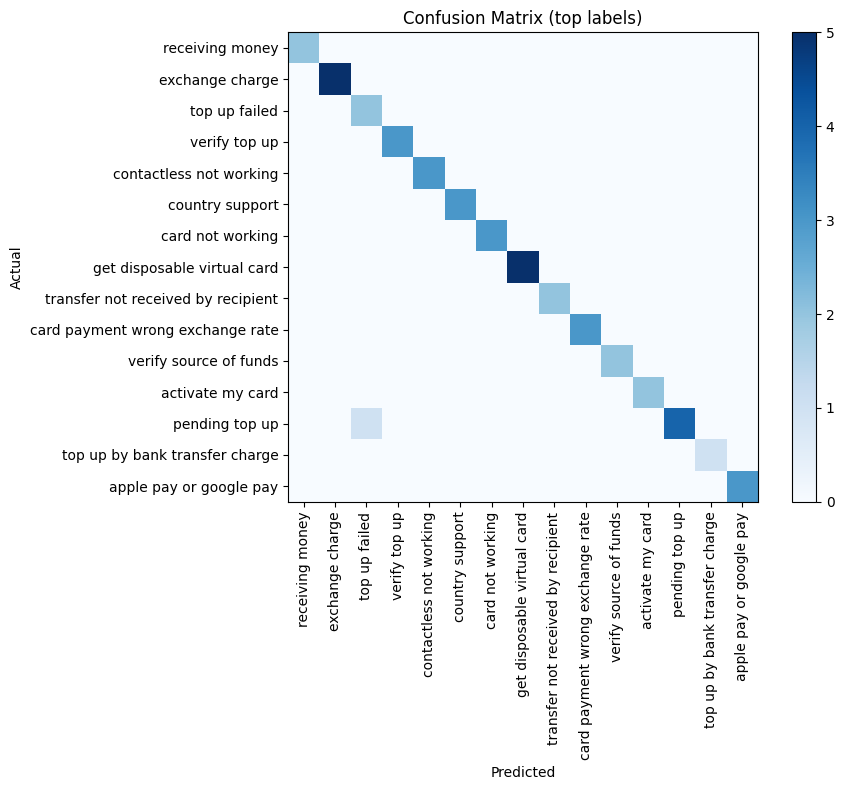

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

top_labels = list(set(gold))[:15]  # just the most common ones for readability
cm = confusion_matrix(gold, preds, labels=top_labels)

plt.figure(figsize=(10, 8))
plt.imshow(cm, cmap="Blues")
plt.xticks(range(len(top_labels)), top_labels, rotation=90)
plt.yticks(range(len(top_labels)), top_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (top labels)")
plt.colorbar()
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()